# Let's try something a bit unconventional...GNN time
### Disclaimer: This is a training exercise, I understand that I'm using a model to predict something that is completely fabricated by me


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from collections import Counter
from torch_geometric.data import InMemoryDataset, Data
import torch_geometric
from torch_geometric.nn import GATv2Conv
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load the data
nodes_gnn = gpd.read_file('nodes_gnn.geojson')
edges_gnn = gpd.read_file('edges_gnn.geojson')

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field bridge: unsupported OGR type: 5


In [4]:
# Check the data
edges_gnn.head()

,u,v,key,osmid,junction,ref,oneway,reversed,length,speed_kph,travel_time,edge_bc,tunnel,width,access,traffic_speed,traffic_time,traffic_lights,traffic_center,geometry
0,249617125,302402633,0,27547575,roundabout,SPexSS10,True,False,53.534697,58.410596,3.299485,0.257884,None,None,None,47.866378,4.026311,False,False,"LINESTRING (5.79e+05 5e+06, 5.79e+05 5e+06, 5...."
1,302402633,332198526,0,27547575,roundabout,SPexSS10,True,False,67.514562,58.410596,4.161102,0.197348,None,None,None,50.341538,4.828069,False,False,"LINESTRING (5.79e+05 5e+06, 5.79e+05 5e+06, 5...."
2,302402633,853019208,0,27706271,None,SPexSS10,True,False,118.332108,58.410596,7.293122,0.060564,None,None,None,55.934287,7.616001,False,False,"LINESTRING (5.79e+05 5e+06, 5.79e+05 5e+06, 5...."
3,249617128,302402587,0,27547575,roundabout,SPexSS10,True,False,34.828924,58.410596,2.146599,0.111161,None,None,None,53.865507,2.327726,False,False,"LINESTRING (5.79e+05 5e+06, 5.79e+05 5e+06, 5...."
4,249617128,302415503,0,27548810,None,None,True,False,43.788035,51.029412,3.089139,0.158156,None,None,None,45.380000,3.473709,False,False,"LINESTRING (5.79e+05 5e+06, 5.79e+05 5e+06, 5...."


<Axes: >

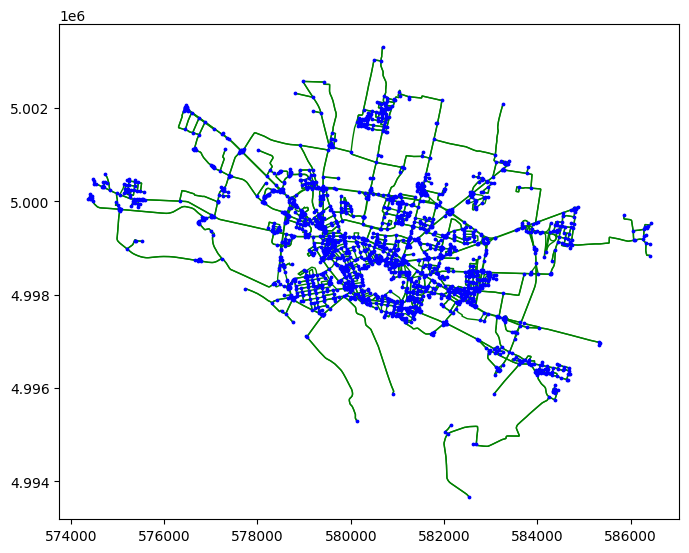

In [5]:
# Check the data
f, ax = plt.subplots(figsize=(8,8))
nodes_gnn.plot(ax=ax, color='blue', markersize=3, zorder=2)
edges_gnn.plot(ax=ax, linewidth= 1, edgecolor= 'green', zorder=1)

In [6]:

# Preprocess the data and prepare the dataset

X = nodes_gnn.drop(columns=['geometry', 'junction', 'highway'])
X = np.array(X.values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(2230, 6)

In [7]:
edges_gnn.columns

Index(['u', 'v', 'key', 'osmid', 'junction', 'ref', 'oneway', 'reversed',
       'length', 'speed_kph', 'travel_time', 'edge_bc', 'tunnel', 'width',
       'access', 'traffic_speed', 'traffic_time', 'traffic_lights',
       'traffic_center', 'geometry'],
      dtype='object')

In [8]:
nodes_gnn['osmid']

0         249617125
1         302402633
2         249617128
3         302402587
4         302415503
           ...     
2225    12327744712
2226    12327744727
2227    12327744726
2228    12327744724
2229    12327744863
Name: osmid, Length: 2230, dtype: int64

In [9]:
Y = edges_gnn['traffic_speed'].values
Y = np.array(Y)
# Prepare edge index 
node_to_id = {}
for i, node in enumerate(nodes_gnn['osmid'].values):
    node_to_id[node] = i

start_node = [node_to_id[i] for i in edges_gnn['u'].values]
end_node = [node_to_id[i] for i in edges_gnn['v'].values]
start = torch.tensor(start_node, dtype=torch.long)
end = torch.tensor(end_node, dtype=torch.long)
edge_index = torch.stack([start, end], dim=0)

In [49]:
# Create dataset for edge regression
class CremonaDataset(InMemoryDataset):
    def __init__(self, edge_index, x, y, pre_transform = None , transform=None):
        super(CremonaDataset, self).__init__('.', transform, None, None)
        
        # Create data object
        data = Data(x=torch.FloatTensor(x), 
                   y=torch.FloatTensor(y), 
                   edge_index=edge_index)
        
        # Set number of nodes and features
        data.num_nodes = x.shape[0]
        data.num_features = x.shape[1]
        data.num_edges = edge_index.shape[1]
        
        # Split data into train/val/test sets (70%/15%/15%)
        np.random.seed(0)
        n_nodes = data.num_nodes
        n_edges = data.num_edges
        indices = np.random.permutation(n_edges)
        #print(n_nodes) #debug
        
        train_idx = indices[:int(0.7 * n_edges)]
        #print(len(train_idx)) #debug
        val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
        test_idx = indices[int(0.85 * n_edges):]
        
        # Create masks
        train_mask = torch.zeros(n_edges, dtype=torch.bool)
        val_mask = torch.zeros(n_edges, dtype=torch.bool)
        test_mask = torch.zeros(n_edges, dtype=torch.bool)
        
        train_mask[train_idx] = True
        val_mask[val_idx] = True
        test_mask[test_idx] = True
        
        data.train_mask = train_mask    #size is still all nodes but only True for train nodes
        data.val_mask = val_mask
        data.test_mask = test_mask
        
        self.data, self.slices = self.collate([data])
        
        print("Dataset created with {} nodes".format(data.num_nodes), "and {} edges".format(edge_index.shape[1]))
    
    
# Set torch device to cuda if available or else cpu
#device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = CremonaDataset(edge_index, X_scaled, Y)
data = dataset[0].to(device)

cpu
Dataset created with 2230 nodes and 4679 edges


In [13]:
# Define hyperparameters
HIDDEN_DIM = 32
LR = 0.01
EPOCHS = 1000

class GATv2(torch.nn.Module):
    def __init__(self, hidden_layer, data, output_dim = 1 , heads=4):
        super(GATv2, self).__init__()
        self.gat1 = GATv2Conv(data.num_features, hidden_layer, heads=heads)
        self.gat2 = GATv2Conv(hidden_layer*heads, hidden_layer, heads=1)
        self.linear = nn.Linear(hidden_layer*2, output_dim)

    def forward(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index
        
        # First layer
        out= self.gat1(x, edge_index)
        out = F.elu(out)
        out = F.dropout(out, p= 0.5, training=self.training)
        
        # Second layer
        out = self.gat2(out, edge_index)
        
        src, dst = edge_index   # src and dst are the start and end nodes of the edges
        out = torch.concat((out[src], out[dst]), dim=1)  # Concatenate the features of the start and end nodes
        
        # Final layer
        out = self.linear(out)
        
        
        return out

# Initialise GCN model instance
model = GATv2(HIDDEN_DIM, data).to(device) 
print(model)

GATv2(
  (gat1): GATv2Conv(6, 32, heads=4)
  (gat2): GATv2Conv(128, 32, heads=1)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


In [15]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [32]:
out = model(data)
out[data.train_mask].squeeze()

tensor([-0.1427, -0.1370, -0.2085,  ..., -0.9312, -0.5491, -0.7228],
       grad_fn=<SqueezeBackward0>)

In [33]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []

print(f"Starting training on {device}...")
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gat.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 234.4087, Val Loss: 186.4976, Test Loss: 180.1832, 
Epoch: 020, Train Loss: 200.3776, Val Loss: 264.3875, Test Loss: 239.0486, 
Epoch: 030, Train Loss: 173.7306, Val Loss: 176.3486, Test Loss: 175.1634, 
Epoch: 040, Train Loss: 172.7240, Val Loss: 196.5365, Test Loss: 186.2450, 
Epoch: 050, Train Loss: 171.9521, Val Loss: 172.2666, Test Loss: 169.4066, 
Epoch: 060, Train Loss: 168.9840, Val Loss: 182.8840, Test Loss: 174.0012, 
Epoch: 070, Train Loss: 159.9568, Val Loss: 166.9359, Test Loss: 162.5611, 
Epoch: 080, Train Loss: 159.8219, Val Loss: 169.6771, Test Loss: 161.2166, 
Epoch: 090, Train Loss: 154.4930, Val Loss: 162.2455, Test Loss: 155.3943, 
Epoch: 100, Train Loss: 139.4103, Val Loss: 151.5747, Test Loss: 146.7805, 
Epoch: 110, Train Loss: 140.8298, Val Loss: 141.2726, Test Loss: 135.5649, 
Epoch: 120, Train Loss: 128.5717, Val Loss: 129.7038, Test Loss: 125.1844, 
Epoch: 130, Train Loss: 121.3130, Val Loss: 126.0711, Test L

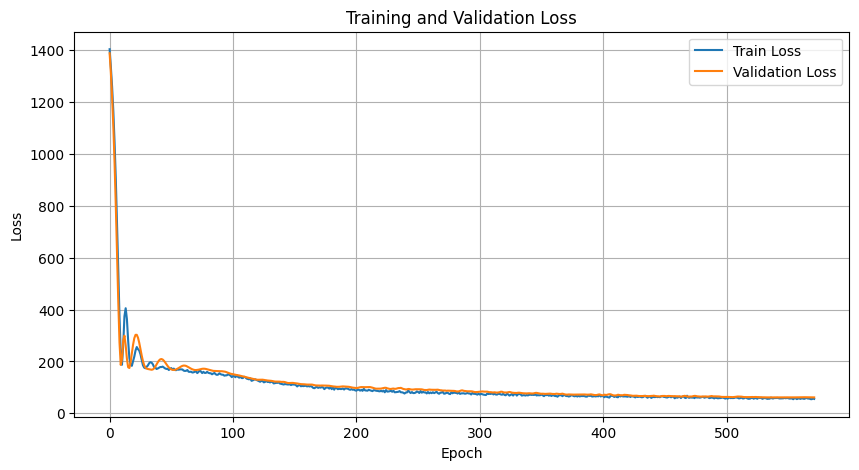

In [34]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

In [16]:
# Load best model for final evaluation
model = GATv2(HIDDEN_DIM, data).to(device)
model.load_state_dict(torch.load('best_CR_gat.pt'))
test_loss = evaluate(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 52.2321


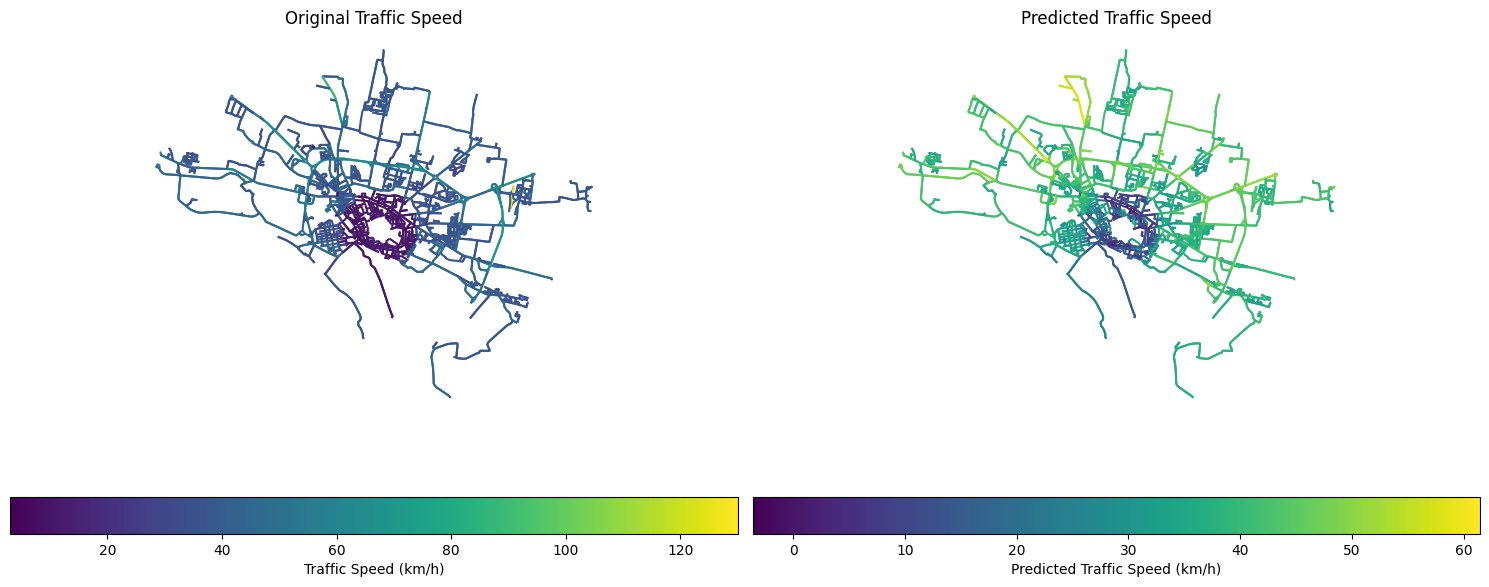

In [17]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()
    
# Add predictions back to the geodataframe for visualization
edges_gnn['predictions'] = predictions

#Visualize the predictions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()

# Plot the predicted traffic speed
edges_gnn.plot(column='predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

# Next steps I would like to try a Graph Transformer and see how it works
## Instead of a GNN, let's try a Graph Transformer
Let's start with TransformerConv, which should still be very similar to GNNs since its attention mechanism is based on the edges

In [33]:
# Define hyperparameters
HIDDEN_DIM = 32
LR = 0.01
EPOCHS = 1000

class GT(torch.nn.Module):
    def __init__(self, hidden_layer, data, output_dim = 1 , heads=4):
        super(GT, self).__init__()
        self.transf1 = torch_geometric.nn.TransformerConv(data.num_features, hidden_layer, heads=heads, concat=True, dropout=0.5)
        self.layernorm1 = torch.nn.LayerNorm(hidden_layer*heads)
        
        self.transf2 = torch_geometric.nn.TransformerConv(hidden_layer*heads, hidden_layer, heads= heads, concat=False) 
        # No concat here because it is the last layer, which means that it will average the heads
        
        
        self.linear = nn.Linear(hidden_layer*2, output_dim)

    def forward(self, data):
        # Get node features and edge index
        x, edge_index = data.x, data.edge_index
        
        # First layer
        out = self.transf1(x, edge_index)
        out = self.layernorm1(out)
        out = F.relu(out)
        
        # Second layer
        out = self.transf2(out, edge_index) # No Norm and activation function because it is the last layer
        
        
        src, dst = edge_index   # src and dst are the start and end nodes of the edges
        out = torch.concat((out[src], out[dst]), dim=1)  # Concatenate the features of the start and end nodes
        
        # Final layer
        out = self.linear(out)    
        return out
    
    def reset_parameters(self):
        self.transf1.reset_parameters()
        self.transf2.reset_parameters()
        self.layernorm1.reset_parameters()
        
# Initialise GT model instance
model = GT(HIDDEN_DIM, data).to(device)
print(model)

GT(
  (transf1): TransformerConv(6, 32, heads=4)
  (layernorm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (transf2): TransformerConv(128, 32, heads=4)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)


In [34]:
# Define loss and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)


def train_tr():
    model.train()
    optimizer.zero_grad()
    # Forward pass
    out = model(data)
    # Compute loss (only on training nodes)
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask]) # squeeze() to remove extra dimension
    # Backward pass
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate_tr(mask):
    model.eval()
    with torch.no_grad():
        out = model(data)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [43]:
out = model(data)
out[data.train_mask].squeeze()

tensor([-0.1709, -0.0359, -0.1923,  ...,  0.0771, -0.1315,  0.2122],
       grad_fn=<SqueezeBackward0>)

In [44]:
# Training loop
best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []


print(f"Starting training on {device}...")
model.reset_parameters()
for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_tr()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate_tr(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gt.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate_tr(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 392.3368, Val Loss: 306.2840, Test Loss: 334.8335, 
Epoch: 020, Train Loss: 199.5694, Val Loss: 183.2386, Test Loss: 164.9207, 
Epoch: 030, Train Loss: 135.6814, Val Loss: 136.5977, Test Loss: 131.3051, 
Epoch: 040, Train Loss: 114.7448, Val Loss: 121.8253, Test Loss: 115.8182, 
Epoch: 050, Train Loss: 100.9660, Val Loss: 108.1492, Test Loss: 96.1487, 
Epoch: 060, Train Loss: 89.1381, Val Loss: 96.8640, Test Loss: 83.4049, 
Epoch: 070, Train Loss: 80.4278, Val Loss: 89.4610, Test Loss: 75.0985, 
Epoch: 080, Train Loss: 74.2848, Val Loss: 83.3621, Test Loss: 68.3617, 
Epoch: 090, Train Loss: 68.8092, Val Loss: 77.7123, Test Loss: 62.2141, 
Epoch: 100, Train Loss: 65.2207, Val Loss: 73.4948, Test Loss: 57.4958, 
Epoch: 110, Train Loss: 60.9342, Val Loss: 68.8402, Test Loss: 53.7680, 
Epoch: 120, Train Loss: 56.9931, Val Loss: 65.8932, Test Loss: 50.5912, 
Epoch: 130, Train Loss: 54.5192, Val Loss: 63.2623, Test Loss: 47.1559, 
Epoch: 14

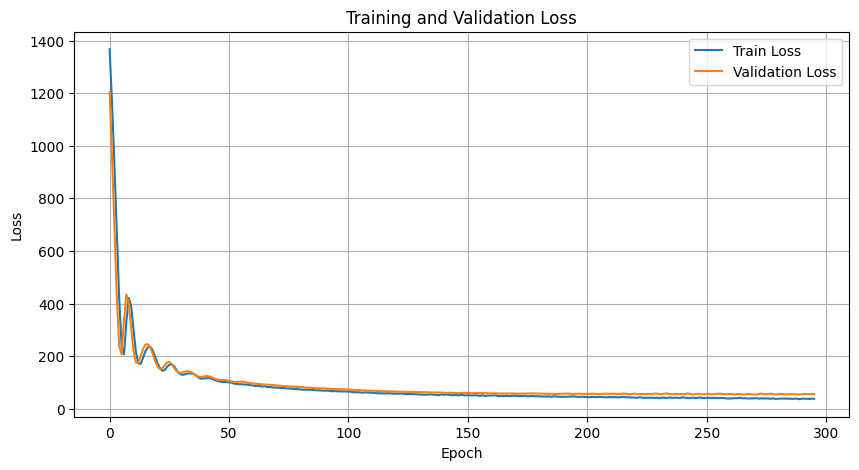

In [45]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()


In [35]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gt.pt'))
test_loss = evaluate_tr(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 38.0412


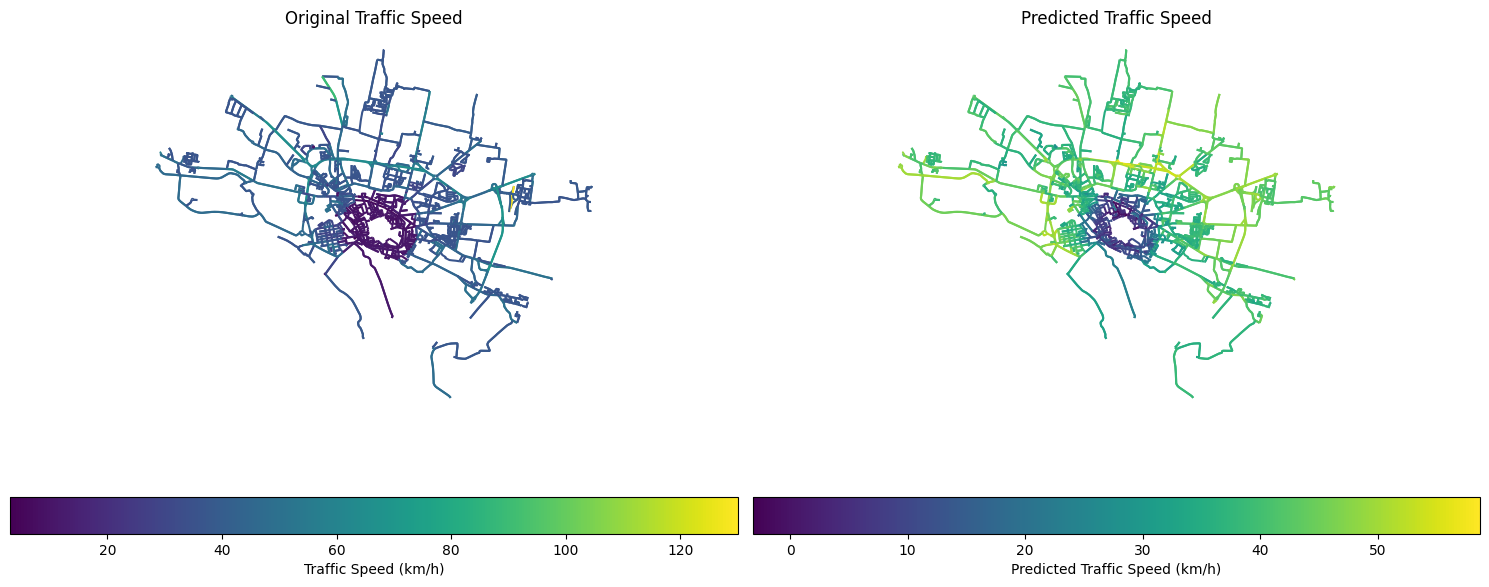

In [47]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data).squeeze().cpu().numpy()
# Add predictions back to the geodataframe for visualization
edges_gnn['predictions_tr'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='predictions_tr', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

Skipping field highway: unsupported OGR type: 5
Skipping field lanes: unsupported OGR type: 5
Skipping field maxspeed: unsupported OGR type: 5
Skipping field name: unsupported OGR type: 5
Skipping field ref: unsupported OGR type: 5
Skipping field width: unsupported OGR type: 5


<Axes: >

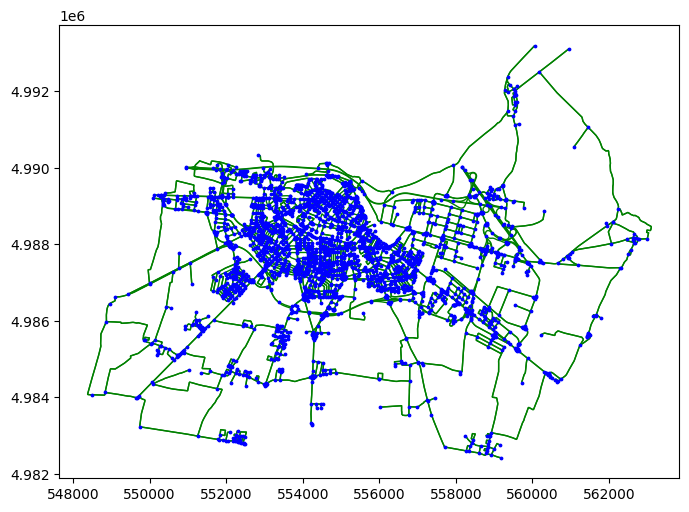

In [24]:
# Load new data
nodes_gnn_pc = gpd.read_file('nodes_piacenza.geojson')
edges_gnn_pc = gpd.read_file('edges_piacenza.geojson')
#plot
f, ax = plt.subplots(figsize=(8,8))
nodes_gnn_pc.plot(ax=ax, color='blue', markersize=3, zorder=2)
edges_gnn_pc.plot(ax=ax, linewidth= 1, edgecolor= 'green', zorder=1)


In [25]:
# Check the data
nodes_gnn_pc.head()

,osmid,y,x,street_count,highway,railway,bc,traffic_lights,geometry
0,92972680,4.989948e+06,552165.187881,3,None,None,0.003208,False,POINT (5.52e+05 4.99e+06)
1,298033861,4.989172e+06,557606.802876,3,motorway_junction,None,0.003207,False,POINT (5.58e+05 4.99e+06)
2,92972786,4.987842e+06,559716.452461,3,motorway_junction,None,0.000000,False,POINT (5.6e+05 4.99e+06)
3,92975190,4.988249e+06,559443.398421,3,None,None,0.000308,False,POINT (5.59e+05 4.99e+06)
4,462186611,4.990028e+06,558166.848537,3,None,None,0.000000,False,POINT (5.58e+05 4.99e+06)


In [26]:
# Preprocess the data and prepare the dataset
X_pc = nodes_gnn_pc.drop(columns=['geometry', 'railway', 'highway'])
X_pc = np.array(X_pc.values)
scaler = StandardScaler()
X_pc_scaled = scaler.fit_transform(X_pc)
X_pc_scaled.shape

(3231, 6)

In [27]:
# Prepare edge index
node_to_id_pc = {}
for i, node in enumerate(nodes_gnn_pc['osmid'].values):
    node_to_id_pc[node] = i
start_node_pc = [node_to_id_pc[i] for i in edges_gnn_pc['u'].values]
end_node_pc = [node_to_id_pc[i] for i in edges_gnn_pc['v'].values]
start_pc = torch.tensor(start_node_pc, dtype=torch.long)
end_pc = torch.tensor(end_node_pc, dtype=torch.long)
edge_index_pc = torch.stack([start_pc, end_pc], dim=0)

# we don't have an Y for this city, but it doesn't matter since we won't use the ground truth to train the model
fake_Y = np.zeros(edge_index_pc.shape[1])

In [28]:
# Create dataset for edge regression
data_pc = CremonaDataset(edge_index_pc, X_pc_scaled, fake_Y)

Dataset created with 3231 nodes and 6930 edges


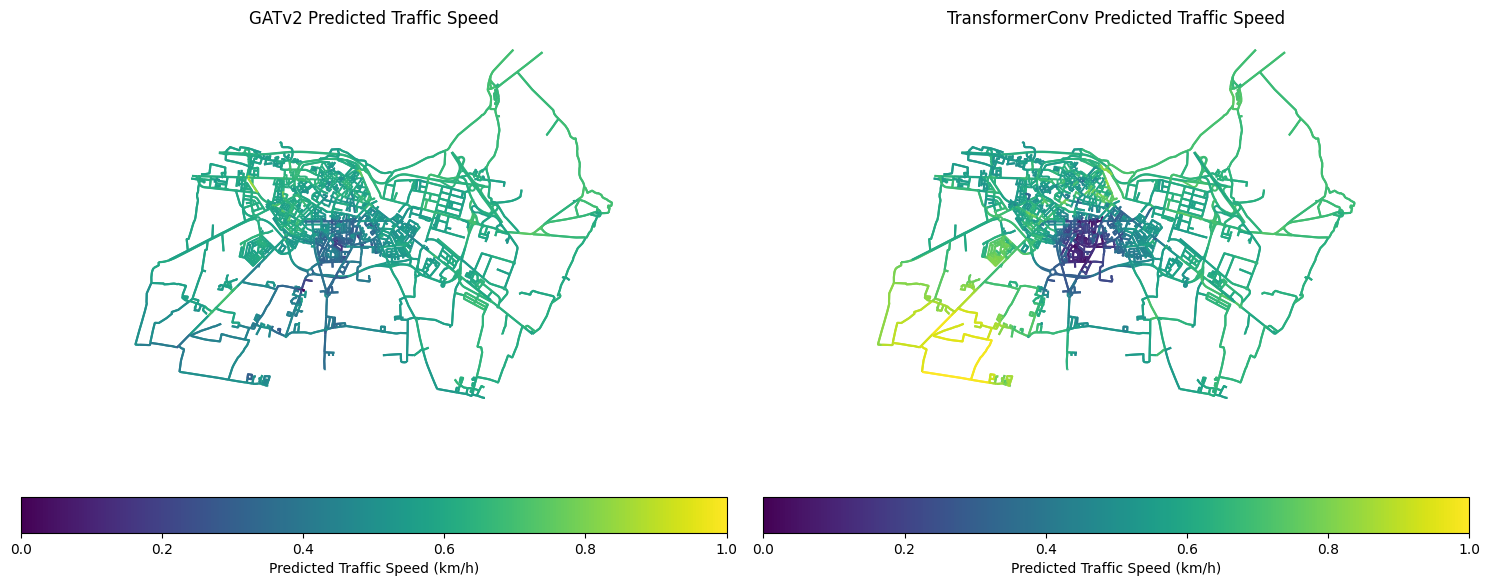

In [37]:
# Compare the models:
gat_model = GATv2(HIDDEN_DIM, data_pc[0]).to(device)
gat_model.load_state_dict(torch.load('best_CR_gat.pt'))
gt_model = GT(HIDDEN_DIM, data_pc[0]).to(device)
gt_model.load_state_dict(torch.load('best_CR_gt.pt'))

gat_model.eval()
gt_model.eval()
with torch.no_grad():
    gat_predictions = gat_model(data_pc[0]).squeeze().cpu().numpy()
    gt_predictions = gt_model(data_pc[0]).squeeze().cpu().numpy()
    
# Normalize the predictions
scaler = MinMaxScaler()
gat_predictions = scaler.fit_transform(gat_predictions.reshape(-1, 1))
gt_predictions = scaler.fit_transform(gt_predictions.reshape(-1, 1))

# Add predictions back to the geodataframe for visualization
edges_gnn_pc['gat_predictions'] = gat_predictions
edges_gnn_pc['gt_predictions'] = gt_predictions

# Visualize the predictions
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))
# Plot the GAT predictions
edges_gnn_pc.plot(column='gat_predictions', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('GATv2 Predicted Traffic Speed')
ax1.set_axis_off()

# Plot the GT predictions
edges_gnn_pc.plot(column='gt_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('TransformerConv Predicted Traffic Speed')
ax2.set_axis_off()

plt.tight_layout()
plt.show()

## Don't stop me now, I'm having such a good time 
### I want to try a proper transformer model, like the GPS 

In [131]:
import argparse
import os.path as osp
from typing import Any, Dict, Optional

import torch
from torch.nn import (
    BatchNorm1d,
    Embedding,
    Linear,
    ModuleList,
    ReLU,
    Sequential,
)
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric.transforms as T
from torch_geometric.datasets import ZINC
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, GPSConv, global_add_pool
from torch_geometric.nn.attention import PerformerAttention

In [151]:
# Preprocess the data and prepare the dataset
transform = T.AddRandomWalkPE( walk_length= 20, attr_name= 'pe')
transform2 = T.AddLaplacianEigenvectorPE(k = 20, attr_name= 'pe')
data = Data(x = torch.FloatTensor(X_scaled), y = torch.FloatTensor(Y), edge_index = edge_index )
data = transform2(data)

data.num_edges

4679

In [155]:
 # Split data into train/val/test sets (70%/15%/15%)
np.random.seed(0)
        
n_edges = data.num_edges
indices = np.random.permutation(n_edges)
        
train_idx = indices[:int(0.7 * n_edges)]
print(len(train_idx)) #debug
val_idx = indices[int(0.7 * n_edges):int(0.85 * n_edges)]
print(len(val_idx)) #debug
test_idx = indices[int(0.85 * n_edges):]
print(len(test_idx)) #debug
        
# Create masks
train_mask = torch.zeros(n_edges, dtype=torch.bool)
val_mask = torch.zeros(n_edges, dtype=torch.bool)
test_mask = torch.zeros(n_edges, dtype=torch.bool)
    
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True
        
data.train_mask = train_mask    #size is still all nodes but only True for train nodes
data.val_mask = val_mask
data.test_mask = test_mask

data.to(device)

3275
702
702


Data(x=[2230, 6], edge_index=[2, 4679], y=[4679], pe=[2230, 20], train_mask=[4679], val_mask=[4679], test_mask=[4679])

In [156]:
class RedrawProjection:
    def __init__(self, model: torch.nn.Module,
                redraw_interval: Optional[int] = None):
        self.model = model
        self.redraw_interval = redraw_interval
        self.num_last_redraw = 0

    def redraw_projections(self):
        if not self.model.training or self.redraw_interval is None:
            return
        if self.num_last_redraw >= self.redraw_interval:
            fast_attentions = [
                module for module in self.model.modules()
                if isinstance(module, PerformerAttention)
            ]
            for fast_attention in fast_attentions:
                fast_attention.redraw_projection_matrix()
            self.num_last_redraw = 0
            return
        self.num_last_redraw += 1



In [157]:
class GPS(torch.nn.Module):
    def __init__(self, channels: int, pe_dim: int, num_layers: int,
                 attn_type: str = 'performer', dropout: float = 0.0):
        super().__init__()

        self.node_emb = Linear(data.x.shape[1], channels - pe_dim)
        self.pe_lin = Linear(20, pe_dim)
        self.pe_norm = BatchNorm1d(20)

        self.convs = ModuleList()
        for _ in range(num_layers):
            nn = Sequential(
                Linear(channels, channels),
                ReLU(),
                Linear(channels, channels),
            )
            conv = GPSConv(channels, GINConv(nn), heads=4,
                           attn_type=attn_type, dropout=dropout)
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(2* channels, channels),
            ReLU(),
            Linear(channels, 1)
            
        )
        self.redraw_projection = RedrawProjection(
            self.convs,
            redraw_interval=1000 if attn_type == 'performer' else None)

    def forward(self, x, pe, edge_index):
        x_pe = self.pe_norm(pe)
        x = torch.cat((self.node_emb(x), self.pe_lin(x_pe)), 1)
        

        for conv in self.convs:
            x = conv(x, edge_index)
        
        # Edge-level prediction
        src, dst = edge_index
        x = torch.cat((x[src], x[dst]), dim=1)
        
        x = self.mlp(x)
        return x

In [158]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GPS(channels= 64, pe_dim=8, num_layers=2, attn_type= 'performer',
            dropout= 0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20,
                              min_lr=0.00001)

In [159]:
model

GPS(
  (node_emb): Linear(in_features=6, out_features=56, bias=True)
  (pe_lin): Linear(in_features=20, out_features=8, bias=True)
  (pe_norm): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0-1): 2 x GPSConv(64, conv=GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )), heads=4, attn_type=performer)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [160]:
def train():
    model.train()
    optimizer.zero_grad()
    model.redraw_projection.redraw_projections()
    out = model(data.x, data.pe, data.edge_index)
    pred = out[data.train_mask].squeeze()
    loss = criterion(out[data.train_mask].squeeze(), data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.pe, data.edge_index)
        pred = out[mask].squeeze()
        true = data.y[mask]
        loss = criterion(pred, true)
    return loss.item()

In [161]:
out = model(data.x, data.pe, data.edge_index)
out[data.val_mask].squeeze().size()

torch.Size([702])

In [163]:
# Training loop
EPOCHS = 500

best_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 30
train_losses, val_losses = [], []

print(f"Starting training on {device}...")

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train()
    train_losses.append(train_loss)
    
    # Evaluate on validation set
    val_loss = evaluate(data.val_mask)
    val_losses.append(val_loss)
    
    # Adjust learning rate
    scheduler.step(val_loss)
    
    # Early stopping check
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_CR_gps.pt')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
        
    
    # Print progress
    if epoch % 10 == 0:
        test_loss  = evaluate(data.test_mask)
        print(f'Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Test Loss: {test_loss:.4f}, ')
        
    # Check for early stopping
    if early_stop_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        break

Starting training on cpu...
Epoch: 010, Train Loss: 49.1944, Val Loss: 132.0441, Test Loss: 114.4902, 
Epoch: 020, Train Loss: 43.8950, Val Loss: 90.6004, Test Loss: 73.4507, 
Epoch: 030, Train Loss: 44.0085, Val Loss: 62.1930, Test Loss: 47.1805, 
Epoch: 040, Train Loss: 44.8627, Val Loss: 55.8493, Test Loss: 35.7667, 
Epoch: 050, Train Loss: 40.1752, Val Loss: 54.2962, Test Loss: 38.6048, 
Epoch: 060, Train Loss: 37.9196, Val Loss: 51.6792, Test Loss: 33.2948, 
Epoch: 070, Train Loss: 37.1567, Val Loss: 55.4124, Test Loss: 36.7453, 
Epoch: 080, Train Loss: 36.8892, Val Loss: 50.6397, Test Loss: 30.3648, 
Epoch: 090, Train Loss: 33.7684, Val Loss: 50.5239, Test Loss: 30.7689, 
Epoch: 100, Train Loss: 35.3482, Val Loss: 48.4193, Test Loss: 28.6882, 
Epoch: 110, Train Loss: 33.2508, Val Loss: 49.8836, Test Loss: 31.0780, 
Epoch: 120, Train Loss: 32.3213, Val Loss: 46.4821, Test Loss: 27.9354, 
Epoch: 130, Train Loss: 32.3789, Val Loss: 45.7430, Test Loss: 27.0681, 
Epoch: 140, Train Los

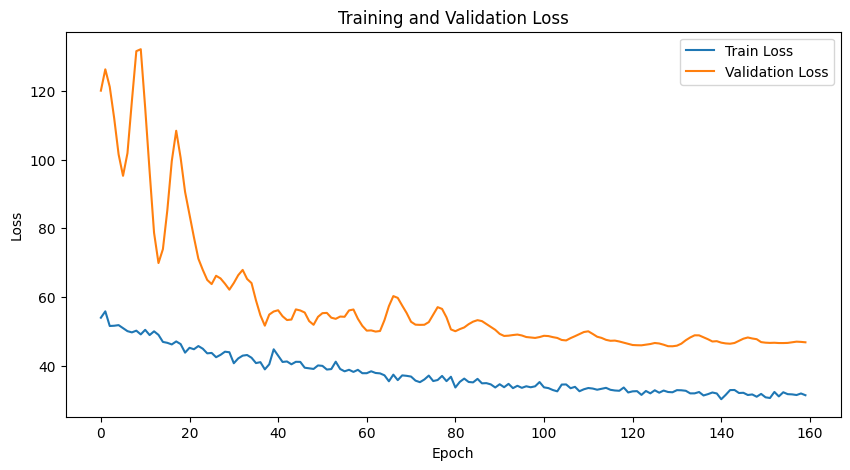

In [164]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [165]:
# Load best model for final evaluation
model.load_state_dict(torch.load('best_CR_gps.pt'))
test_loss = evaluate(data.test_mask)
print(f'Final Test Results - Loss: {test_loss:.4f}')

Final Test Results - Loss: 27.0681


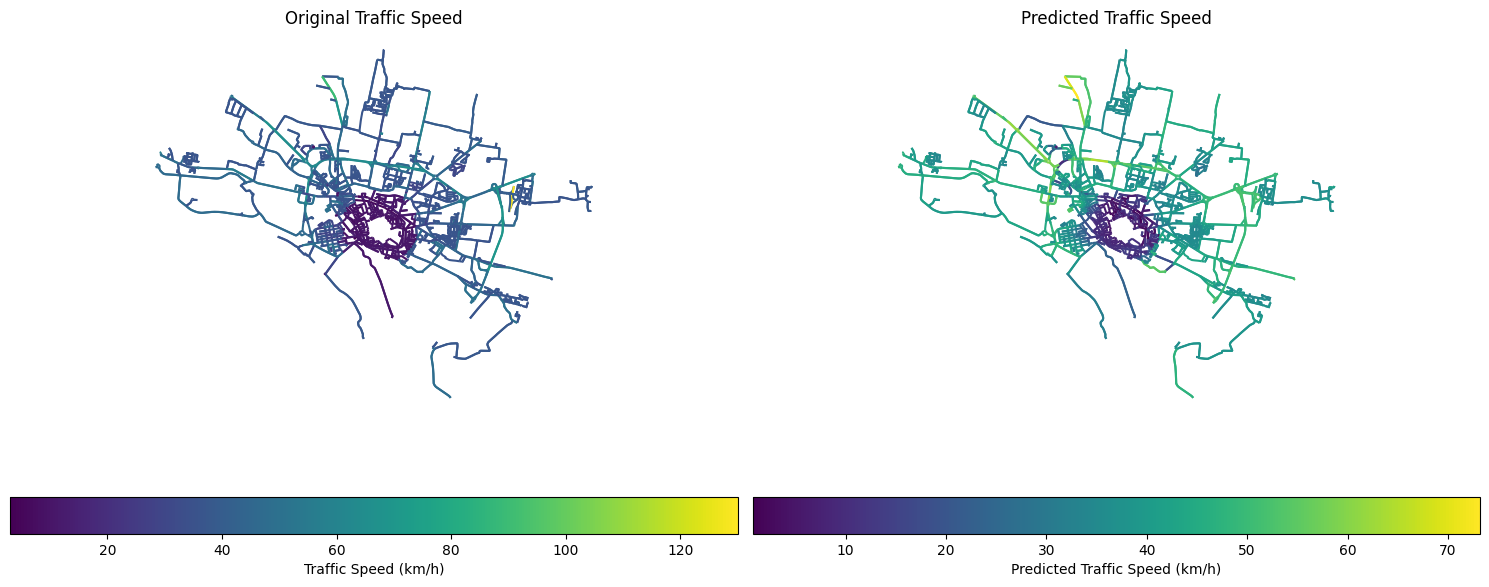

In [166]:
# Generate predictions for all nodes
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.pe, data.edge_index).squeeze().cpu().numpy()
# Add predictions back to the geodataframe for visualization
edges_gnn['gps_predictions'] = predictions
#Visualize the predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Plot the original traffic speed
edges_gnn.plot(column='traffic_speed', ax=ax1, legend=True, cmap='viridis', legend_kwds={
    'label': "Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax1.set_title('Original Traffic Speed')
ax1.set_axis_off()
# Plot the predicted traffic speed
edges_gnn.plot(column='gps_predictions', ax=ax2, legend=True, cmap='viridis', legend_kwds={
    'label': "Predicted Traffic Speed (km/h)",
    'orientation': "horizontal"
})
ax2.set_title('Predicted Traffic Speed')
ax2.set_axis_off()
plt.tight_layout()
plt.show()